In [8]:

import os
import geopandas as gpd
import pickle
import networkx as nx
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Ensure we're in the right dir (same as 01)
print("Current dir:", os.getcwd())

# --- LOAD SAVED DATA ---
# Load graph
with open("data/road_graph.pkl", "rb") as f:
    G = pickle.load(f)
print(f"Loaded graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Load POIs as GeoDataFrame (GeoJSON)
pois_points = gpd.read_file("data/pois_with_nodes.geojson")
print(f"Loaded {len(pois_points)} POIs (pre-parse)")
print(pois_points.head())
print("POI columns:", pois_points.columns.tolist())

# --- AUTO-PARSE: Fix stringified nearest_node (from GeoJSON) ---
import re

def parse_node_str(node_str):
    """
    Parse string like '(np.float64(376842.915), np.float64(720919.121))' to tuple of floats.
    """
    if isinstance(node_str, (tuple, list)):
        return tuple(float(c) if isinstance(c, np.float64) else float(c) for c in node_str)
    
    # Clean string: Remove 'np.float64(' and trailing ')'
    clean_str = re.sub(r'np\.float64\(', '', str(node_str))
    clean_str = re.sub(r'\)$', '', clean_str)
    clean_str = clean_str.replace('(', '').replace(')', '').replace(' ', '')
    # Split and float
    try:
        nums = [float(x.strip()) for x in clean_str.split(',')]
        if len(nums) == 2:
            return tuple(nums)
        else:
            raise ValueError(f"Invalid node format: {node_str}")
    except:
        raise ValueError(f"Failed to parse node string: {node_str}")

# Apply parsing
pois_points["nearest_node"] = [parse_node_str(node) for node in pois_points["nearest_node"]]
print(f"Post-parse sample nearest_node: {pois_points['nearest_node'].iloc[0]} (type: {type(pois_points['nearest_node'].iloc[0])})")

# Verify nearest_nodes are in graph
missing_nodes = [node for node in pois_points["nearest_node"] if node not in G]
if missing_nodes:
    print(f"Warning: {len(missing_nodes)} POI nodes not in graph.")
else:
    print("All POI nodes found in graph—good!")

# --- SWITCH TO LARGEST COMPONENT (for connected analysis) ---
print("\n=== SWITCHING TO LARGEST COMPONENT ===")
components = list(nx.connected_components(G))
largest_comp = max(components, key=len)
print(f"Original components: {len(components)}")
print(f"Largest: {len(largest_comp)} nodes ({len(largest_comp)/G.number_of_nodes()*100:.1f}%)")

# Create subgraph
G = G.subgraph(largest_comp).copy()
print(f"Subgraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Filter POIs to those in subgraph
original_pois = len(pois_points)
pois_points = pois_points[pois_points["nearest_node"].isin(G.nodes)].copy()
print(f"Filtered POIs: {len(pois_points)} / {original_pois} ({len(pois_points)/original_pois*100:.1f}%)")

# Re-verify
missing_after = [node for node in pois_points["nearest_node"] if node not in G]
print(f"All filtered POI nodes in subgraph: {len(missing_after) == 0}")

Current dir: /home/ridwan-ayinde/Desktop/MIT Emerging Talent/Final Project/4_data_analysis/routing
Loaded graph: 15248 nodes, 16310 edges
Loaded 143 POIs (pre-parse)
         fclass                                      nearest_node  \
0  market_place  (np.float64(376842.915), np.float64(720919.121))   
1  market_place  (np.float64(377726.413), np.float64(720729.665))   
2          park  (np.float64(378082.368), np.float64(719409.216))   
3   arts_centre  (np.float64(377866.976), np.float64(719466.665))   
4         pitch  (np.float64(377946.581), np.float64(719658.794))   

   snap_distance                       geometry  
0      70.660796  POINT (376779.993 720951.273)  
1      19.546977  POINT (377732.671 720748.183)  
2      19.953265  POINT (378102.319 719409.507)  
3      44.752749  POINT (377880.409 719423.976)  
4      42.588509  POINT (377906.133 719672.125)  
POI columns: ['fclass', 'nearest_node', 'snap_distance', 'geometry']
Post-parse sample nearest_node: (376842.915, 72091

In [10]:
# --- EXPLORE POIs (FILTERED) ---
print("\nUnique POI fclass values (in largest component):")
if 'fclass' in pois_points.columns:
    unique_fclass = pois_points['fclass'].value_counts()
    print(unique_fclass)
    print(f"\nTop 10 categories:\n{unique_fclass.head(10)}")
else:
    print("No 'fclass' column found—check data.")

# Sample POI nodes (use 'fclass' as identifier since no 'name')
sample_pois = pois_points.head(5)
print("\nSample POIs and their nodes:")
print(sample_pois[["fclass", "nearest_node"]])


Unique POI fclass values (in largest component):
fclass
pitch               46
market_place        12
school              11
hospital             9
park                 9
sports_centre        6
swimming_pool        5
clinic               3
graveyard            3
tower                3
hostel               3
mall                 2
police               2
hotel                2
museum               2
courthouse           2
stadium              2
shelter              2
university           2
lighthouse           1
embassy              1
water_tower          1
arts_centre          1
community_centre     1
theatre              1
water_works          1
track                1
college              1
bookshop             1
bank                 1
library              1
fire_station         1
supermarket          1
Name: count, dtype: int64

Top 10 categories:
fclass
pitch            46
market_place     12
school           11
hospital          9
park              9
sports_centre     6
swimming_po

In [11]:
# --- COMPUTE SHORTEST PATHS ---
def get_poi_by_category(pois_df, category_col, category_value):
    """Helper: Get first POI matching category."""
    mask = pois_df[category_col] == category_value
    if mask.any():
        return pois_df[mask].iloc[0]
    return None

def compute_poi_distances(pois_df, src_category, tgt_category, category_col='fclass', max_pairs=25):
    """
    Compute shortest distances from src_category POIs to tgt_category POIs.
    Limits to max_pairs for speed (e.g., first few of each).
    """
    src_pois = pois_df[pois_df[category_col] == src_category]["nearest_node"].tolist()
    tgt_pois = pois_df[pois_df[category_col] == tgt_category]["nearest_node"].tolist()
    
    # Limit for demo/performance
    src_pois = src_pois[:int(max_pairs**0.5)]  # e.g., ~5 per side for 25 pairs
    tgt_pois = tgt_pois[:int(max_pairs**0.5)]
    
    distances = []
    for src in src_pois:
        for tgt in tgt_pois:
            try:
                dist = nx.shortest_path_length(G, source=src, target=tgt, weight="length")
                distances.append({
                    "src_fclass": src_category,
                    "src_node": src,
                    "tgt_fclass": tgt_category,
                    "tgt_node": tgt,
                    "distance_m": dist
                })
            except nx.NetworkXNoPath:
                distances.append({
                    "src_fclass": src_category,
                    "src_node": src,
                    "tgt_fclass": tgt_category,
                    "tgt_node": tgt,
                    "distance_m": np.nan
                })
    return pd.DataFrame(distances)

In [12]:
# Example: Distance between a 'market_place' and a 'park' (based on your data)
market = get_poi_by_category(pois_points, 'fclass', 'market_place')  # First in filtered
park_poi = get_poi_by_category(pois_points, 'fclass', 'park')

if market is not None and park_poi is not None:
    src_node = market["nearest_node"]
    tgt_node = park_poi["nearest_node"]
    
    # Compute shortest path length (Dijkstra with weights)
    try:
        dist = nx.shortest_path_length(G, source=src_node, target=tgt_node, weight="length")
        path = nx.shortest_path(G, source=src_node, target=tgt_node, weight="length")
        print(f"\nExample: Shortest distance between 'market_place' and 'park': {dist:.0f} meters")
        print(f"Path length (nodes): {len(path)}")
        print("Sample path nodes:", path[:5], "..." if len(path) > 5 else "")
    except nx.NetworkXNoPath:
        print("No path found—unlikely now with subgraph!")
else:
    print("No 'market_place' or 'park' found in filtered POIs—check Cell 4 and adjust.")


Example: Shortest distance between 'market_place' and 'park': 2277 meters
Path length (nodes): 59
Sample path nodes: [(376842.915, 720919.121), (376834.577, 720886.822), (376834.176, 720871.855), (376835.145, 720860.002), (376839.03, 720847.757)] ...


In [14]:
# --- FAST ALL-PAIRS SHORTEST PATHS (Dijkstra Per POI) ---
print(f"Computing optimized distances for {len(pois_points)} POIs...")

# Prepare empty matrix
dist_matrix = pd.DataFrame(
    index=pois_points.index,
    columns=pois_points.index,
    dtype=float
)

# Pre-extract all nearest nodes
nearest_nodes = pois_points["nearest_node"].to_dict()

for i in pois_points.index:
    src_node = nearest_nodes[i]

    # Run Dijkstra *once* for this POI
    dist_from_i = nx.single_source_dijkstra_path_length(G, src_node, weight="length")

    for j in pois_points.index:
        tgt_node = nearest_nodes[j]

        if i == j:
            dist_matrix.loc[i, j] = 0
        else:
            dist_matrix.loc[i, j] = dist_from_i.get(tgt_node, np.nan)

print("Done computing optimized distance matrix.")
print(dist_matrix.head())

# Stats
valid_dists = dist_matrix.stack().dropna()
print(f"\nStats: Avg={valid_dists.mean():.0f}m | Max={valid_dists.max():.0f}m | Min={valid_dists.min():.0f}m")
print(f"Valid pairs: {len(valid_dists)}")

# Save
dist_matrix.to_csv("data/full_poi_distances.csv")
print("Saved optimized full distances to data/full_poi_distances.csv")


Computing optimized distances for 140 POIs...
Done computing optimized distance matrix.
           0            1            2            3            4    \
0     0.000000  1210.954032  2276.616996  1997.748399  1933.328307   
1  1210.954032     0.000000  1730.759175  1451.890578  1243.278998   
2  2276.616996  1730.759175     0.000000   278.868597   487.480176   
3  1997.748399  1451.890578   278.868597     0.000000   208.611580   
4  1933.328307  1243.278998   487.480176   208.611580     0.000000   

           5            6            7            8            9    ...  \
0  2222.680032  2363.517741  3695.180551  2608.030601  2796.659114  ...   
1  1532.630724  1626.531050  3149.923839  2031.525304  2136.180266  ...   
2   472.628087   640.197112  1583.407854   452.215422   701.902236  ...   
3   482.474690   781.844679  1698.033261   610.282202   859.969016  ...   
4   289.351726   573.233099  1906.644841   788.246305   892.901267  ...   

           133          134          135

In [ ]:
# Save filtered POIs for future (GeoJSON)
pois_points.to_file("data/pois_largest_component.geojson", driver="GeoJSON")
print("Saved filtered POIs to data/pois_largest_component.geojson")

Saved filtered POIs to data/pois_largest_component.geojson


=== GLOBAL DISTANCE STATS ===
Total unique pairs: 9,800
Average: 5382m (5.4km)
Median: 4967m
Min/Max: 0m / 12233m
Std Dev: 3498m


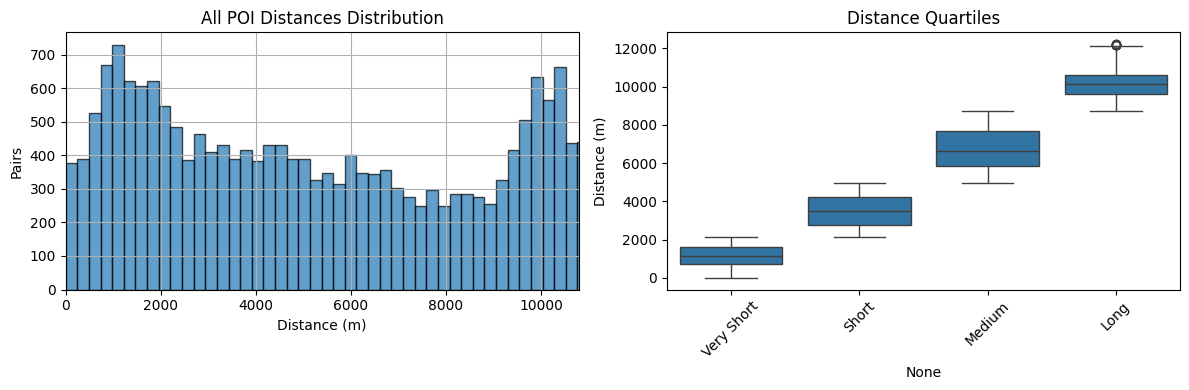


=== HOME-TO-MARKET ACCESS (hostel/hotel → market_place) ===
Avg distance: 7329m (7.3km)
% homes <1km from a market: 3.3%
% homes <3km: 15.0%


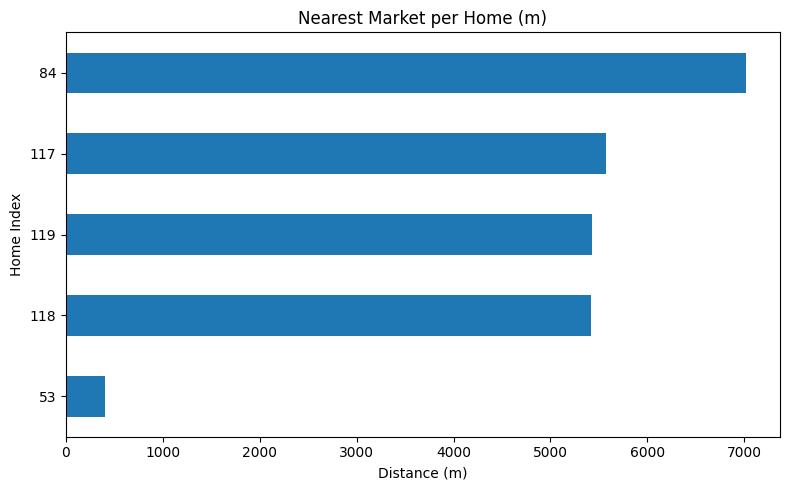


Saved summary to data/path_analysis_home_market_summary.csv


In [15]:
# --- FULL MATRIX INSIGHTS: HOME (hostel/hotel) TO MARKET ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Choose POIs
home_idx = pois_points[pois_points['fclass'].isin(['hostel', 'hotel'])].index
market_idx = pois_points[pois_points['fclass'] == 'market_place'].index

# Subset distance matrix
home_market = dist_matrix.loc[home_idx, market_idx].stack().dropna()

# Global distance stats (all POIs)
valid_dists = dist_matrix.stack().dropna()
print("=== GLOBAL DISTANCE STATS ===")
print(f"Total unique pairs: {len(valid_dists)//2:,}")
print(f"Average: {valid_dists.mean():.0f}m ({valid_dists.mean()/1000:.1f}km)")
print(f"Median: {valid_dists.median():.0f}m")
print(f"Min/Max: {valid_dists.min():.0f}m / {valid_dists.max():.0f}m")
print(f"Std Dev: {valid_dists.std():.0f}m")

# Histogram
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
valid_dists.hist(bins=50, edgecolor='k', alpha=0.7)
plt.title("All POI Distances Distribution")
plt.xlabel("Distance (m)")
plt.ylabel("Pairs")
plt.xlim(0, valid_dists.quantile(0.95))

# Quantile boxplot
plt.subplot(1,2,2)
quantiles = pd.qcut(valid_dists, q=4, labels=['Very Short', 'Short', 'Medium', 'Long'])
sns.boxplot(x=quantiles, y=valid_dists)
plt.title("Distance Quartiles")
plt.ylabel("Distance (m)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Home-to-market access
if len(home_market) > 0:
    print("\n=== HOME-TO-MARKET ACCESS (hostel/hotel → market_place) ===")
    print(f"Avg distance: {home_market.mean():.0f}m ({home_market.mean()/1000:.1f}km)")
    print(f"% homes <1km from a market: {(home_market < 1000).mean()*100:.1f}%")
    print(f"% homes <3km: {(home_market < 3000).mean()*100:.1f}%")
    
    nearest_market_per_home = home_market.groupby(level=0).min()
    nearest_market_per_home.sort_values().plot(kind='barh', figsize=(8,5),
                                               title="Nearest Market per Home (m)")
    plt.xlabel("Distance (m)")
    plt.ylabel("Home Index")
    plt.tight_layout()
    plt.show()

# Export summary
summary_stats = pd.DataFrame({
    'Metric': ['Avg All Pairs (m)', 'Median (m)', 'Max (m)', 'Std (m)',
               'Home-Market Avg (m)', '% Homes <3km Market'],
    'Value': [valid_dists.mean(), valid_dists.median(), valid_dists.max(), valid_dists.std(),
              home_market.mean() if len(home_market) > 0 else np.nan,
              (home_market < 3000).mean()*100 if len(home_market) > 0 else np.nan]
})
summary_stats.to_csv("data/path_analysis_home_market_summary.csv", index=False)
print("\nSaved summary to data/path_analysis_home_market_summary.csv")


In [24]:
import folium
from folium.plugins import MarkerCluster
import networkx as nx
import osmnx as ox


In [26]:
# Look at the first node
first_node = list(G.nodes(data=True))[0]
print(first_node)


((378920.893, 720480.8), {})


In [27]:
import pyproj

# Define projection transformer
transformer = pyproj.Transformer.from_crs("epsg:3857", "epsg:4326", always_xy=True)

path_coords_wgs84 = [transformer.transform(x, y)[::-1] for x, y in path]  # (lat, lon)


In [28]:
# Apply transformer to all POIs
pois_points["latlon"] = pois_points["nearest_node"].apply(
    lambda coord: transformer.transform(coord[0], coord[1])[::-1]
)


In [29]:
import folium
from folium.plugins import MarkerCluster

# Create map centered on start of path
m = folium.Map(location=path_coords_wgs84[0], zoom_start=14)

# Plot shortest path
folium.PolyLine(
    path_coords_wgs84,
    weight=6,
    color='blue',
    popup="Shortest Path"
).add_to(m)

# Start & end markers
folium.Marker(path_coords_wgs84[0], popup="Home/Hotel/Hostel", icon=folium.Icon(color='purple')).add_to(m)
folium.Marker(path_coords_wgs84[-1], popup="Market Place", icon=folium.Icon(color='orange')).add_to(m)



In [30]:
# Create cluster for POIs
poi_cluster = MarkerCluster(name="POIs").add_to(m)

# Color code relevant POIs
colors = {
    'home': 'purple',
    'hotel': 'purple',
    'hostel': 'purple',
    'market_place': 'orange',
    'default': 'gray'
}

for _, row in pois_points.iterrows():
    color = colors.get(row['fclass'], colors['default'])
    folium.CircleMarker(
        location=row["latlon"],
        radius=5,
        popup=f"{row['fclass']} (ID: {row.name})",
        color=color,
        fill=True,
        fillOpacity=0.7
    ).add_to(poi_cluster)


In [31]:
save_path = "data/lagos_poi_sample_map.html"
m.save(save_path)
print(f"Saved interactive map to {save_path}")
m  # Display in Jupyter


Saved interactive map to data/lagos_poi_sample_map.html


In [2]:
import math

In [3]:
# Simple dummy line to mark notebook as modified
_ = 42  

# or a simple math operation
import math
x = math.sqrt(16)  # just to create a new line

# or a print statement (harmless)
print("Notebook updated")  # this won’t affect your existing logic


Notebook updated
